In [21]:
import sys
sys.path.append("../")

from jax import vmap, jit
import jax.numpy as jnp
import numpy as np
import healpy as hp

from utils import create_mask as cm

## HEALPix

In [216]:
def mod(dividends, divisor):
    """ Return dividends (array) mod divisor (double)
        Stolen from Nick's code
    """

    output = np.zeros(len(dividends))

    for i in range(len(dividends)): 
        output[i] = dividends[i]
        done=False
        while (not done):
            if output[i] >= divisor:
                output[i] -= divisor
            elif output[i] < 0.:
                output[i] += divisor
            else:
                done=True

    return output


def rho_NFW(r, gamma=1., r_s=20.):
    """ Generalized NFW profile
    """
    return (r / r_s) ** -gamma * (1 + (r / r_s)) ** (-3 + gamma) 

def rGC(s_ary, b_ary, l_ary, rsun=8.224):
    """ Distance to GC as a function of LOS distance, latitude, longitude
    """
    return jnp.sqrt(s_ary ** 2 - 2. * rsun * jnp.transpose(jnp.outer(s_ary, jnp.cos(b_ary) * jnp.cos(l_ary))) + rsun ** 2)

nside = 128
mask = cm.make_mask_total(nside=nside, band_mask = True, band_mask_range = 0, mask_ring = True, inner = 0, outer = 40)
mask_restrict = np.where(mask == 0)[0]
theta_ary, phi_ary = hp.pix2ang(nside, mask_restrict)
npix = hp.nside2npix(nside)
mask_idx = jnp.arange(npix)[~mask]
b_ary = np.pi / 2. - theta_ary
l_ary = mod(phi_ary + np.pi, 2. * np.pi) - np.pi
s_ary = jnp.linspace(0, 40, 500)

@jit
def get_NFW2_template(gamma=1.2):

    # LOS integral of density^2
    int_rho2_temp = jnp.trapz(rho_NFW(rGC(s_ary, b_ary, l_ary), gamma=gamma) ** 2, s_ary, axis=1)

    int_rho2 = jnp.zeros(npix)
    int_rho2 = int_rho2.at[mask_idx].set(int_rho2_temp)

    return int_rho2

In [217]:
%%timeit
get_NFW2_template(gamma=1.3)

401 ms ± 56.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


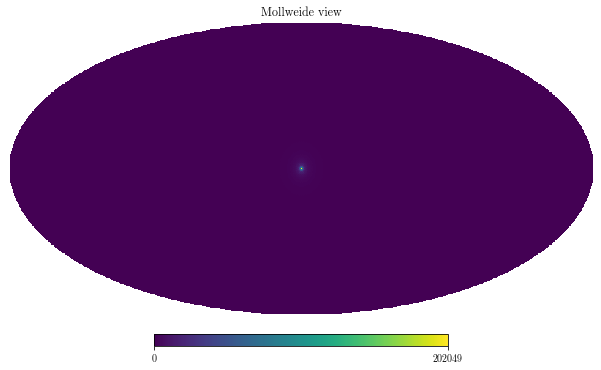

In [218]:
hp.mollview(get_NFW2_template())

## Cartesian

In [455]:
from einops import rearrange
import matplotlib.pyplot as plt

In [456]:
pixel_size = 0.5
extent = 20

coords_ary = jnp.deg2rad(jnp.arange(-extent, extent, pixel_size))
l_ary, b_ary = jnp.meshgrid(coords_ary, coords_ary)

In [457]:
npix = int(len(coords_ary) ** 2)

In [458]:
l_ary_flat = rearrange(l_ary, 'x y -> (x y)')
b_ary_flat = rearrange(b_ary, 'x y -> (x y)')

In [459]:
@jit
def get_NFW2_template_cart(gamma=1.2):
    # LOS integral of density^2
    int_rho2 = jnp.trapz(rho_NFW(rGC(s_ary, b_ary_flat, l_ary_flat), gamma=gamma) ** 2, s_ary, axis=1)
    int_rho2 = rearrange(int_rho2, '(x y) -> x y', x=len(coords_ary))
    return int_rho2 / jnp.mean(int_rho2)

In [460]:
%%timeit
get_NFW2_template_cart()

99.4 ms ± 5.94 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [461]:
get_NFW2_template_cart(gamma=1.)

DeviceArray([[0.21958098, 0.22442128, 0.22934878, ..., 0.23436123,
              0.22934878, 0.22442128],
             [0.22442128, 0.2294907 , 0.23465729, ..., 0.239919  ,
              0.23465729, 0.2294907 ],
             [0.22934878, 0.23465729, 0.2400739 , ..., 0.2455966 ,
              0.2400739 , 0.23465729],
             ...,
             [0.23436123, 0.239919  , 0.2455966 , ..., 0.25139236,
              0.2455966 , 0.239919  ],
             [0.22934878, 0.23465729, 0.2400739 , ..., 0.2455966 ,
              0.2400739 , 0.23465729],
             [0.22442128, 0.2294907 , 0.23465729, ..., 0.239919  ,
              0.23465729, 0.2294907 ]], dtype=float32)

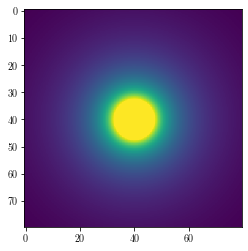

In [469]:
plt.imshow(get_NFW2_template_cart(gamma=1.), vmax=4)

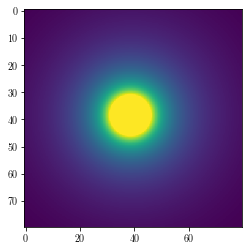

In [470]:
from utils.cart import make_wcs, to_cart

temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=80, pixelsize=0.5)
temp_gce_cart /= np.mean(temp_gce_cart)

plt.imshow(temp_gce_cart, vmax=4)

In [254]:
get_NFW2_template_cart_vmap = jit(vmap(get_NFW2_template_cart))

In [263]:
# get_NFW2_template_cart_vmap(jnp.linspace(0.5, 1.5, 10))

## Disk

In [396]:
def R_z_GC(s, b, l, rsun=8.224):
    """ Convert lon/lat to cylindrical coordinates
    
        :param s: distance from Earth [kpc]
        :param b: latitude in galactic coordinates [rad]
        :param l: longitude in galactic coordinates [rad]
        :returns: distance from GC [kpc]
    """
    R = jnp.sqrt(s ** 2 - 2 * rsun * s * jnp.cos(l) + rsun ** 2)
    z = s * jnp.tan(b)
    return R, z

In [397]:
def rho_V_Lorimer(R, z, zs=0.63, B = 2.75, C=5.94, rsun=8.224):
    """ Spatial number density according to Lorimer disk profile (unnormalized)
        Eq. (6) of Bartels et al (1805.11097), after removing constant terms
    """
    return (R / rsun) ** B * jnp.exp(-C * ((R - rsun) / rsun)) * jnp.exp(-jnp.abs(z) / zs)


def rho_V_Lorimer_lonlat(s, b, l, zs, B, C, rsun):
    """ Lorimer density, this time in lot/lat
    """

    R, z = R_z_GC(s, b, l)
    return rho_V_Lorimer(R, z, zs, B, C, rsun)

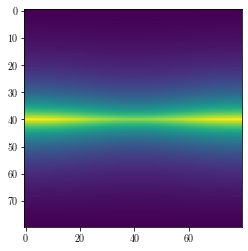

In [447]:
def L_integ_Lorimer(b, l, zs=0.63, B=2.75, C=5.94, rsun=8.224):
    """ Line-of-sight integral (discrete sum) for Lorimer disk profile
    """
    s_ary = jnp.linspace(0, 100, 1500)  # Integration range
    return jnp.trapz(rho_V_Lorimer_lonlat(s_ary, b, l, zs, B, C, rsun), s_ary)

L_integ_Lorimer_vmap = jit(vmap(L_integ_Lorimer, in_axes=(0, 0, None, None, None)))

def rho_lorimer(zs=0.63, B=2.75, C=5.94):
    return rearrange(L_integ_Lorimer_vmap(b_ary_flat, l_ary_flat, zs, B, C), '(x y) -> x y', x=len(coords_ary))

plt.imshow(rho_lorimer())

In [448]:
rho_lorimer_vmapped = jit(vmap(rho_lorimer))

In [452]:
param_linspace = jnp.linspace(0.1, 1, 10)
rho_disk_var = rho_lorimer_vmapped(param_linspace, param_linspace, param_linspace)